# EI Tuning — Wilson-Cowan Whole-Brain Model

각 셀은 독립적인 파트를 담당한다. **파라미터 수정은 Cell 2에서만 한다.**

In [1]:
# JAX 메모리 설정: import 전에 반드시 실행해야 한다
import os
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
os.environ.setdefault("XLA_PYTHON_CLIENT_ALLOCATOR", "platform")

import jax
jax.config.update("jax_enable_x64", False)

print(f"backend : {jax.default_backend()}")
print(f"devices : {jax.devices()}")
print(f"jax_enable_x64 : {jax.config.jax_enable_x64}")

from config              import Config
from data_loader         import load_data
from model               import build_network
from part1_fic           import run_fic
from part2_eib           import run_eib
from part3_gradient      import run_gradient_optimization
from part4_dbs           import run_dbs_stimulation
from pipeline_contracts  import ParamSet, StateBundle, capture_internal_state, capture_network_delay_history


backend : gpu
devices : [CudaDevice(id=0)]
jax_enable_x64 : False


## Cell 2 — Config

**파라미터 수정은 이 셀에서만 한다.**

## Dataset 선택 (PPMI 216-node)

`PPMI_SC_FC_cell.mat` 의 N번째 subject 데이터를 사용한다.
아래 `SUBJECT_IDX` (0-based) 로 어떤 subject 를 쓸지 설정한다.


In [2]:
# ── Dataset 고정 (ppmi: 216-node SC/FC from .mat) ───────────────
dataset = "ppmi"

# ════════════════════════════════════════════════════════════════
#  사용할 subject 선택 (0-based index, 0 ~ N-1)
# ════════════════════════════════════════════════════════════════
SUBJECT_IDX = 1          # ← N번째 데이터 (0부터 시작)

# ════════════════════════════════════════════════════════════════
#  Noise LEVEL (가산 잡음 표준편차 σ) — 클수록 잡음 ↑, 0 이면 무잡음
# ════════════════════════════════════════════════════════════════
NOISE_LEVEL = 0.02       # ← additive_noise_sigma 로 전달

MAT_PATH = "/scratch/home/wog3597/vbi/PPMI_SC_FC_cell.mat"
PPMI_DIR = "ppmi"        # 변환된 CSV 출력 디렉토리

import os
import numpy as _np_ppmi
import scipy.io as _sio_ppmi

os.makedirs(PPMI_DIR, exist_ok=True)

_m = _sio_ppmi.loadmat(MAT_PATH)
#   1열 subject_num, 2열 SC weight, 3열 SC tract_length, 4열 FC matrix
#   stack 형태(N,216,216)가 있으면 우선 사용, 없으면 cell 에서 추출
_subj = _np_ppmi.asarray(_m["subject_num"]).ravel()
_N_SUBJ = _subj.shape[0]
assert 0 <= SUBJECT_IDX < _N_SUBJ, f"SUBJECT_IDX must be 0..{_N_SUBJ-1}, got {SUBJECT_IDX}"

if "weight_stack" in _m:
    _w  = _np_ppmi.asarray(_m["weight_stack"])[SUBJECT_IDX]
    _tl = _np_ppmi.asarray(_m["tract_length_stack"])[SUBJECT_IDX]
    _fc = _np_ppmi.asarray(_m["fc_stack"])[SUBJECT_IDX]
else:
    _w  = _np_ppmi.asarray(_m["weight_cell"][SUBJECT_IDX, 0])
    _tl = _np_ppmi.asarray(_m["tract_length_cell"][SUBJECT_IDX, 0])
    _fc = _np_ppmi.asarray(_m["fc_cell"][SUBJECT_IDX, 0])

_w  = _np_ppmi.nan_to_num(_w,  nan=0.0).astype(_np_ppmi.float64)
_tl = _np_ppmi.nan_to_num(_tl, nan=0.0).astype(_np_ppmi.float64)
_fc = _np_ppmi.nan_to_num(_fc, nan=0.0).astype(_np_ppmi.float64)
_n_nodes = _w.shape[0]
assert _w.shape == _tl.shape == _fc.shape == (_n_nodes, _n_nodes), "matrix shape mismatch"

_subj_id = int(_subj[SUBJECT_IDX])

# CSV 저장 (data_loader 는 header 없는 CSV 로 읽는다)
_sc_csv  = os.path.join(PPMI_DIR, "weight.csv")
_len_csv = os.path.join(PPMI_DIR, "tract_length.csv")
_fc_csv  = os.path.join(PPMI_DIR, "FC.csv")
_reg_txt = os.path.join(PPMI_DIR, "region_labels.txt")

_np_ppmi.savetxt(_sc_csv,  _w,  delimiter=",")
_np_ppmi.savetxt(_len_csv, _tl, delimiter=",")
_np_ppmi.savetxt(_fc_csv,  _fc, delimiter=",")

# region label 매핑: PPMI 216 = Schaefer200 cortical(1-200, "7Networks_*")
#   + 16 subcortical(201-216, PD25: red nucleus/SN/STN/caudate/putamen/GPe/GPi/thalamus L·R).
# Custom_Schaefer200_7net_PD25subcortex.txt(216줄, "<idx> <label>")의 label 컬럼만 추출해 저장
# → derive_cortex_subcortex_indices가 cortex/subcortex 분리 → cc/cross/ss block corr 활성.
_LABEL_SRC = os.path.join(os.path.dirname(os.path.abspath(MAT_PATH)).replace("/vbi", "/optim"),
                          "Custom_Schaefer200_7net_PD25subcortex.txt")
if not os.path.exists(_LABEL_SRC):
    _LABEL_SRC = "Custom_Schaefer200_7net_PD25subcortex.txt"   # optim/ 작업 디렉토리 fallback
with open(_LABEL_SRC, "r", encoding="utf-8-sig") as _fh:
    _raw_labels = [ln.strip() for ln in _fh if ln.strip()]
assert len(_raw_labels) == _n_nodes, (
    f"label count {len(_raw_labels)} != n_nodes {_n_nodes} ({_LABEL_SRC})")
_labels = []
for _ln in _raw_labels:
    _parts = _ln.split(None, 1)                      # "<idx> <label>" → label
    _labels.append(_parts[1].strip() if len(_parts) == 2 and _parts[0].isdigit() else _ln)
with open(_reg_txt, "w") as _fh:
    for _lab in _labels:
        _fh.write(_lab + "\n")
_n_ctx = sum(1 for _l in _labels if _l.startswith(("7Networks_", "Cortex_")))

print(f"Dataset: ppmi  (subject idx={SUBJECT_IDX} / {_N_SUBJ},  subject_num={_subj_id})")
print(f"  n_nodes = {_n_nodes}")
print(f"  weight     -> {_sc_csv}")
print(f"  tract_len  -> {_len_csv}")
print(f"  FC         -> {_fc_csv}")
print(f"  region_txt -> {_reg_txt}  (cortex={_n_ctx}, subcortex={_n_nodes - _n_ctx})  src={_LABEL_SRC}")

_DATASET_PARAMS = {
    "ppmi": dict(
        # RWW 모델 사용 — WC 파라미터는 Config 요구사항으로 유지(모델 미참조). mouse 값 차용.
        wc_c_ei_init=1.0,   # RWW 표준 J_i (10.0이면 S_e가 0 근처로 짓눌려 FIC 불가)
        fic_target_firing_rate_hz=2.0,   # 진단용 Hz 표시 (FIC 제어는 fic_target_se=S_e gating)
        # PPMI 216-node atlas — STN 노드 매핑 불명 → DBS skip (아래 DBS 셀)
        dbs_target_regions={},
        bold_hrf_k1=5.6,
        bold_hrf_V0=0.02,
        bold_hrf_tau_s=0.8,
        bold_hrf_tau_f=0.4,
        bold_hrf_scaling=1.0 / 3.0,
        bold_hrf_duration_ms=32_000.0,
        sc_csv=_sc_csv,
        length_csv=_len_csv,
        fc_csv=_fc_csv,
        region_txt=_reg_txt,
        tract_conduction_speed=3.0,
        additive_noise_sigma=NOISE_LEVEL,
    ),
}

_p = _DATASET_PARAMS[dataset]
print(f"  sc_csv={_p['sc_csv']}")


Dataset: ppmi  (subject idx=1 / 45,  subject_num=101070)
  n_nodes = 216
  weight     -> ppmi/weight.csv
  tract_len  -> ppmi/tract_length.csv
  FC         -> ppmi/FC.csv
  region_txt -> ppmi/region_labels.txt  (cortex=200, subcortex=16)  src=/scratch/home/wog3597/optim/Custom_Schaefer200_7net_PD25subcortex.txt
  sc_csv=ppmi/weight.csv


In [ ]:
cfg = Config(
    # ── 데이터 경로 ──────────────────────────────────────────
    region_txt                          = _p["region_txt"],
    sc_csv                              = _p["sc_csv"],
    length_csv                          = _p["length_csv"],
    fc_csv                              = _p["fc_csv"],
    cache_version                       = f"v_ppmi216_s{SUBJECT_IDX}",
    cache_run_label                     = "ppmi216",

    # ── 시뮬레이션 공통 ──────────────────────────────────────
    integration_dt_ms                   = 1.0,
    warmup_duration_ms                  = 720_000,
    # -- Patch 13: Bold HRF parameters -------------------
    bold_hrf_k1          = _p["bold_hrf_k1"],
    bold_hrf_V0          = _p["bold_hrf_V0"],
    bold_hrf_tau_s       = _p["bold_hrf_tau_s"],
    bold_hrf_tau_f       = _p["bold_hrf_tau_f"],
    bold_hrf_scaling     = _p["bold_hrf_scaling"],
    bold_hrf_duration_ms = _p["bold_hrf_duration_ms"],

    bold_repetition_time_ms             = 1000.0,
    tract_conduction_speed              = _p["tract_conduction_speed"],
    additive_noise_sigma                = _p["additive_noise_sigma"],

    # ── Part 1 — FIC (구버전 notebook 로직) ─────────────────
    fic_target_firing_rate_hz           = _p["fic_target_firing_rate_hz"],
    fic_learning_rate                   = 0.5,    # EI_Tuning 참조값 (init c_ei=1.0 기준)
    fic_max_iterations                  = 2000,
    fic_early_stop_patience             = 500,
    fic_step_duration_ms                = 1_000,
    fic_step_skip_tr                    = 0,
    freeze_c_ei_after_fic               = False,   # True: Part2(EIB)에서만 c_ei 동결. Part3는 항상 c_ei 최적화

    # ── Part 2 — EIB (구버전 notebook 로직) ─────────────────
    eib_max_iterations                  = 10000,
    eib_internal_fic_learning_rate      = 0.05,
    eib_max_weight_learning_rate        = 0.002,
    eib_bold_window_samples             = 720,
    eib_snapshot_save_interval          = 50,
    connectivity_weight_max             = 1.5,

    eib_posthoc_duration_ms             = 720_000,
    eib_posthoc_skip_tr                 = 60,

    # ── Part 3 — Full Gradient (구버전 notebook 로직) ───────
    optimizer_learning_rate             = 0.0005,
    optimizer_max_steps                 = 200,
    optimizer_chunk_steps               = 10,
    optimizer_bold_window_tr            = 40,   # 216노드 AD tape ~0.37GiB/TR: 80→29.5GiB OOM, 40→~15GiB (base limit 17.7GiB)
    optimizer_bold_skip_tr              = 10,   # window 40 - skip 10 → 유효 ~30 TR (메모리 한계상 짧음)


    # ── EIB score 계산용 ──────────────────────────────────────
    pd_fit_region_count                 = 14,
    full_brain_fc_loss_weight           = 1.00,
    correlation_loss_weight             = 0.80,   # EIB scoring (keep)
    rmse_loss_weight                    = 0.20,   # EIB scoring (keep)

    # ── Patch 9: Gradient 3-term loss weights ────────────────
    optimizer_global_corr_weight        = 0.40,   # alpha: global FC corr
    optimizer_nodewise_corr_weight      = 0.40,   # beta:  node-wise FC corr
    optimizer_rmse_weight               = 0.20,   # gamma: global FC RMSE

    # ── Subcortex FC fitting emphasis: 블록 loss 점유율(합=1) ─
    # whole-brain corr의 cortex-cortex 쏠림 완화. balanced=0.50/0.40/0.10.
    # data_loader가 atlas edge수로 per-edge 환산(216/416 무관). subcortex
    # 라벨 분리 안 되는 atlas(mouse CHA)는 자동 off. 바꾸면 cache_version 갱신.
    fc_block_share_cortex               = 0.50,
    fc_block_share_cross                = 0.40,
    fc_block_share_subsub               = 0.10,

    # ── Block-split corr loss 가중치(part2 선택 + part3 gradient) ──
    # corr 항을 cc/cross/ss로 쪼개 edge수 무관 동등 가중 → subcortex fit 균형.
    # 합=1로 정규화(상대비). subcortex 없는 atlas는 cc만 활성→whole corr fallback.
    corr_block_weight_cc                = 0.40,   # cortex-cortex corr
    corr_block_weight_cross             = 0.40,   # cross (ctx↔sub) corr
    corr_block_weight_subsub            = 0.20,   # sub-sub corr (edge 적어 noisy→낮게)

    # ── Part 4 — DBS ─────────────────────────────────────────
    # DBS target regions (dataset-specific)
    dbs_target_regions               = _p["dbs_target_regions"],

    dbs_pulse_amplitude                 = 10.0,
    dbs_stimulation_frequency_hz        = 130.0,
    dbs_pre_stimulation_duration_ms     = 60_000.0,
    dbs_stimulation_duration_ms         = 60_000.0,

    wc_c_ei_init = _p["wc_c_ei_init"],
)
cfg.print_summary()

## Cell 3 — Data Loading

SC / tract_length / FC 로드 및 전처리. weights/delays/fc_target 행렬을 시각화한다.

[DATA] cortex=200  subcortex=16  FC block share ctx/cross/sub=0.5/0.4/0.1
Cache stored here: /scratch/home/wog3597/optim/cache/ppmi216/v_ppmi216_s1_N216_scb2b55a810f_fceb166eed5d
[DATA] n_nodes=216  SC nonzero=6860
[DATA] weights:   min=0.0000e+00  max=1.0000e+00
[DATA] fc_target: min=-6.2057e-01  max=9.5844e-01
[DATA] delays:    min=0.00ms  max=99.67ms  (speed=3.0 mm/ms)
[DATA] SC mask:   6860 / 46656  (14.7%)
[DATA] cache_tag = v_ppmi216_s1_N216_scb2b55a810f_fceb166eed5d
[DATA] Graph type: DenseDelayGraph


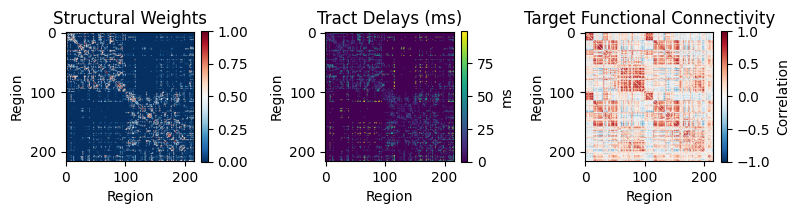

In [4]:
data = load_data(cfg)


## Cell 4 — Build Network & Warmup

In [5]:
network, initial_state, bold_monitor, warmup_result = build_network(cfg, data)

initial_params = ParamSet.default(data["n_nodes"], c_ei_init=cfg.wc_c_ei_init).sanitize(
    data["sc_mask"], cfg.connectivity_weight_max
)

bundle_init = StateBundle.from_warmup(
    warmup_result          = warmup_result,
    bold_monitor_template  = bold_monitor,
    initial_params         = initial_params,
    internal_state         = capture_internal_state(initial_state),
    delay_history          = capture_network_delay_history(network),
    stage                  = "warmup",
)

print(bundle_init)

[MODEL] Running warmup simulation...
[MODEL] Warmup done — E mean=0.8748  I mean=0.9148
[MODEL] Graph type: DenseDelayGraph
StateBundle(stage='warmup', c_ei_frozen=False, init_dyn_shape=(2, 216))


## Pipeline timing diagnostics (read-only, Patch 3)

각 단계의 예상 소요 시간만 표시한다. 시뮬레이션을 실행하지 않으며 캐시를 건드리지 않는다.
JAX backend / device 확인, dispatch latency, 단계별 step×per-step 추정치 합산.

In [6]:
# === Pipeline timing diagnostics (Patch 3) ===
from timing_utils import estimate_stage, print_estimates, print_gpu_summary
import time as _t, jax, jax.numpy as _jnp

print_gpu_summary()

# JAX per-dispatch latency micro-benchmark
_n = data['n_nodes']
_x = _jnp.ones((_n, 2), dtype=_jnp.float32)
_f = jax.jit(lambda x: x * 1.0001 + 0.0001)
_f(_x).block_until_ready()  # warmup
_t0 = _t.perf_counter()
for _ in range(200):
    _x = _f(_x)
_x.block_until_ready()
_jax_latency = (_t.perf_counter() - _t0) / 200
print(f'\nJAX per-dispatch latency ≈ {_jax_latency*1000:.3f} ms (N={_n})')

_tr_ms = cfg.bold_repetition_time_ms
_cost = 0.0008  # GPU 기준 fallback (sim 1ms당 약 0.8ms wall)

# DBS baseline+stim per target: config의 dbs_pre_stimulation_duration_ms + dbs_stimulation_duration_ms
_dbs_pre = getattr(cfg, 'dbs_baseline_duration_ms', None)
if _dbs_pre is None:
    _dbs_pre = getattr(cfg, 'dbs_pre_stimulation_duration_ms', 60_000.0)
_dbs_total_per_target = float(_dbs_pre) + float(cfg.dbs_stimulation_duration_ms)

_estimates = [
    estimate_stage('FIC',
        n_steps=int(cfg.fic_max_iterations),
        fallback_step_sec=cfg.fic_step_duration_ms * _cost),
    estimate_stage('EIB-search',
        n_steps=int(cfg.eib_max_iterations),
        fallback_step_sec=_tr_ms * _cost),
    estimate_stage('EIB-posthoc',
        n_steps=1,
        fallback_step_sec=cfg.eib_posthoc_duration_ms * _cost),
    estimate_stage('Gradient',
        n_steps=int(cfg.optimizer_max_steps),
        fallback_step_sec=cfg.optimizer_bold_window_tr * _tr_ms * _cost),
    estimate_stage('DBS (per target)',
        n_steps=len(cfg.dbs_target_regions),
        fallback_step_sec=_dbs_total_per_target * _cost),
]
print_estimates(_estimates)

print('\n[hint] Patch 3: cfg.posthoc_parallel=True 시 EIB-posthoc ~20-30% 단축.')
print('[hint] cfg.optimizer_chunk_steps=5~10 시 Gradient ~10% 단축 (수렴 dynamics 변경 감수).')
print('[hint] 위 예측은 ±50% 오차. 실측은 각 run_* 의 [STAGE] 라인 참조.')

                        JAX backend / device summary                        
             backend: gpu
        device_count: 1
             devices: ['cuda:0']
      default_device: cuda:0
         x64_enabled: False

JAX per-dispatch latency ≈ 0.040 ms (N=216)
            Pipeline timing estimates (analytical + JAX latency)            
[             FIC] steps=  2000  per-step=  800.00ms  total≈26.7min
[      EIB-search] steps= 10000  per-step=  800.00ms  total≈2.22h
[     EIB-posthoc] steps=     1  per-step=576000.00ms  total≈9.6min
[        Gradient] steps=   200  per-step=64000.00ms  total≈3.56h
[DBS (per target)] steps=     0  per-step=96000.00ms  total≈0.0s
----------------------------------------------------------------------------
                          TOTAL (excl. caching, compile)  ≈ 6.38h

[hint] Patch 3: cfg.posthoc_parallel=True 시 EIB-posthoc ~20-30% 단축.
[hint] cfg.optimizer_chunk_steps=5~10 시 Gradient ~10% 단축 (수렴 dynamics 변경 감수).
[hint] 위 예측은 ±50% 오차. 실측은 각 run_* 의 [S

## Cell 5 — Part 1: FIC

구버전 notebook 로직: **1초 step × 2000** 반복, `c_ei`는 아직 동결하지 않는다.

Loading fic_v_ppmi216_s1_N216_scb2b55a810f_fceb166eed5d_se0.25_eta0p5_steps2000_dur1000_skip0_bestbundlev4_fp06b1f1303652 from cache, last modified 2026-06-15 17:31:51
[FIC] c_ei updated.  mean c_ei = 1.2185  final rE_hz = 4.973 Hz


/scratch/home/wog3597/optim/part1_fic.py:668: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/scratch/home/wog3597/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


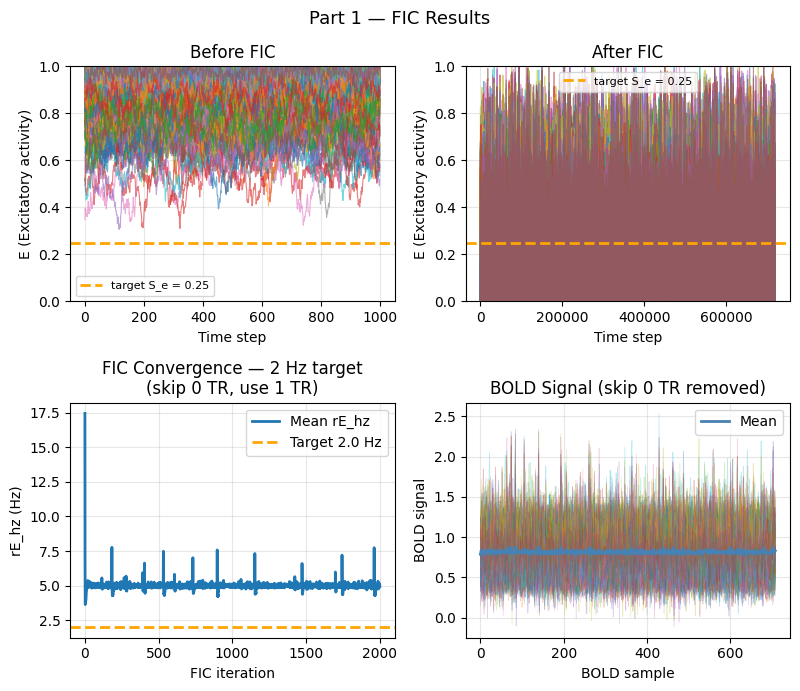

[FIC] FC comparison  Pre-opt corr=0.0150, Pre-opt rmse=0.3068  Post-FIC corr=-0.0081, Post-FIC rmse=0.3098


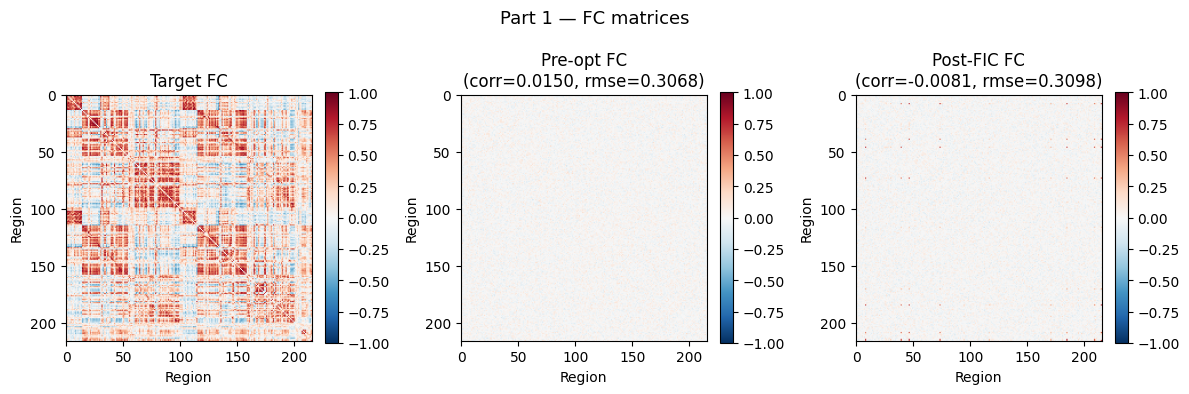

[FIC] c_ei_frozen=False  mean c_ei=1.2185
StateBundle(stage='fic', c_ei_frozen=False, init_dyn_shape=(2, 216))


In [7]:
# Part 1: FIC — 구버전 notebook 로직 (c_ei는 이후 단계에서도 계속 업데이트)
bundle_fic = run_fic(
    network   = network,
    bundle_in = bundle_init,
    cfg       = cfg,
    data      = data,
)
assert not bundle_fic.params.c_ei_frozen, "Old-logic FIC should keep c_ei unfrozen"
print(f"[FIC] c_ei_frozen={bundle_fic.params.c_ei_frozen}  mean c_ei={bundle_fic.params.c_ei.mean():.4f}")
print(bundle_fic)


## Cell 6 — Part 2: EIB Tuning

구버전 notebook 로직: **150 TR window / 8000 step / EIB 중에도 c_ei 업데이트**.

Loading eib_v_ppmi216_s1_N216_scb2b55a810f_fceb166eed5d_win720_etaF0p05_etaE0p002_steps10000_frozen0_fp90d90d251bb3 from cache, last modified 2026-06-22 15:37:56


/scratch/home/wog3597/optim/part2_eib.py:635: UserWarning: Glyph 53456 (\N{HANGUL SYLLABLE TAM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/scratch/home/wog3597/optim/part2_eib.py:635: UserWarning: Glyph 49353 (\N{HANGUL SYLLABLE SAEG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/scratch/home/wog3597/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 53456 (\N{HANGUL SYLLABLE TAM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/scratch/home/wog3597/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49353 (\N{HANGUL SYLLABLE SAEG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


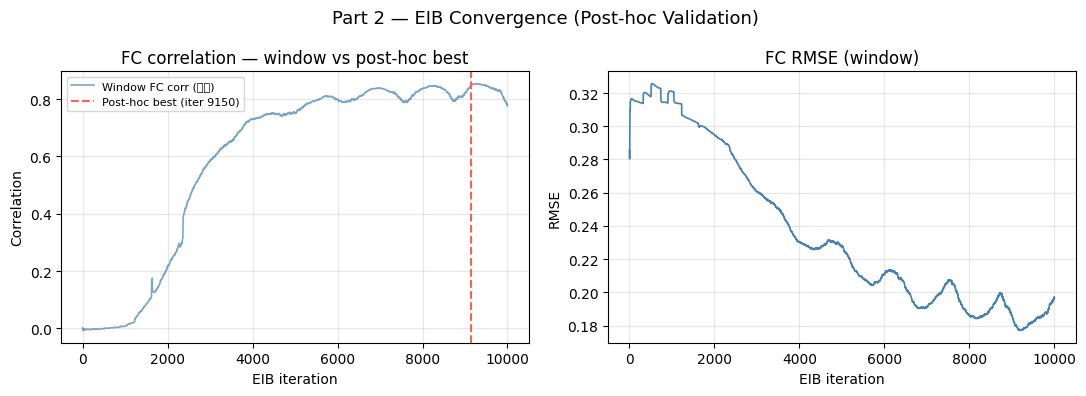

[EIB] FC comparison  pre corr=-0.0081, pre rmse=0.3098  post corr=0.7919, post rmse=0.2440


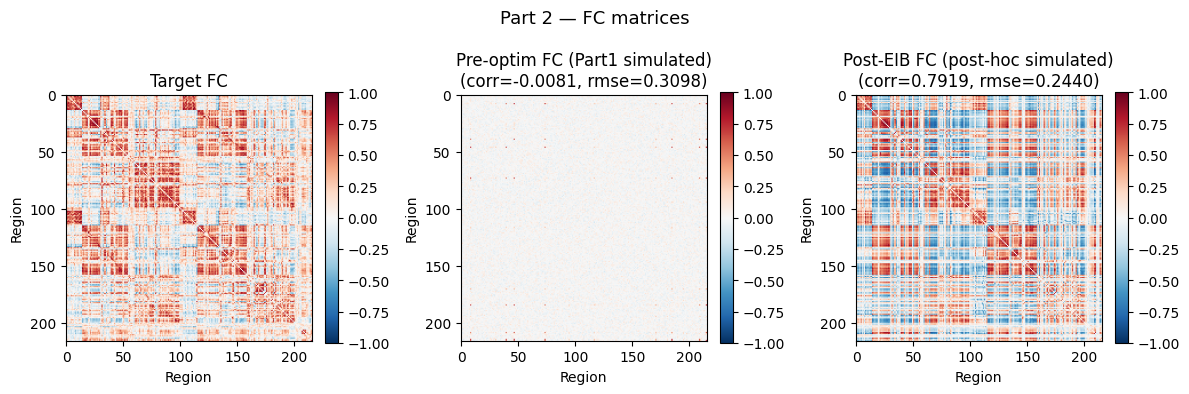

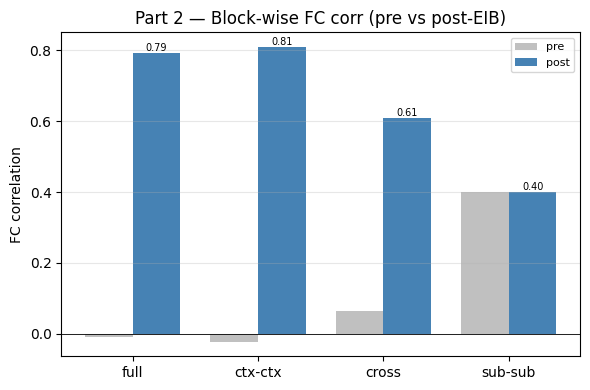

[EIB] Block corr post  full=0.7922  ctx-ctx=0.8088  cross=0.6096  sub-sub=0.3987
[EIB] stage=eib  c_ei_frozen=False
StateBundle(stage='eib', c_ei_frozen=False, init_dyn_shape=(2, 216))


In [8]:
# Part 2: EIB — 구버전 notebook 로직 (c_ei + wLRE/wFFI 동시 튜닝)
bundle_eib = run_eib(
    network   = network,
    bundle_in = bundle_fic,
    cfg       = cfg,
    data      = data,
)
assert not bundle_eib.params.c_ei_frozen, "Old-logic EIB should keep c_ei unfrozen"
print(f"[EIB] stage={bundle_eib.stage}  c_ei_frozen={bundle_eib.params.c_ei_frozen}")
print(bundle_eib)


## Cell 7 — Part 3: Full-matrix Gradient Optimization

구버전 notebook 로직: **96 TR / skip 8 / c_ei·wLRE·wFFI 모두 dense 최적화**.

In [9]:
# Part 3: Full-matrix Gradient Optimization
bundle_grad = run_gradient_optimization(
    network   = network,
    bundle_in = bundle_eib,
    warmup_bundle = bundle_init,
    cfg       = cfg,
    data      = data,
)
print(f"[Part3] stage={bundle_grad.stage}  c_ei_frozen={bundle_grad.params.c_ei_frozen}")
print(bundle_grad)


Running computations for grad_v_ppmi216_s1_N216_scb2b55a810f_fceb166eed5d_TR80_SKIP20_STEPS200_LR0p0005_frozen0_fpc3bf0e3582a4
[Part3] Initial loss: 0.224565  |  Full Corr: 0.6450
  t1_opt=80000ms (80.0s)  max_steps=200  chunk=10  lr=0.0005  fc_skip_tr=20
[GRAD] Starting full-matrix optimization  (total 200 steps, chunk=10)
      Step         Loss   FullCorr     BestLoss   Step/s    Elapsed        ETA
----------------------------------------------------------------------------------


E0622 20:09:37.028227  310585 gpu_hlo_schedule.cc:817] The byte size of input/output arguments (31803414269) exceeds the base limit (18979068313). This indicates an error in the calculation!
W0622 20:09:37.054161  310585 hlo_rematerialization.cc:3198] Can't reduce memory use below 29.55GiB (31733731733 bytes) by rematerialization; only reduced to 29.74GiB (31928996285 bytes), down from 29.74GiB (31928996285 bytes) originally
E0622 20:09:38.099805  310585 pjrt_stream_executor_client.cc:3314] Execution of replica 0 failed: RESOURCE_EXHAUSTED: Failed to allocate request for 13.90GiB (14929920000B) on device ordinal 0


XlaRuntimeError: RESOURCE_EXHAUSTED: Failed to allocate request for 13.90GiB (14929920000B) on device ordinal 0

## Cell 7B — Part 1/2/3 결과 plot 저장

Part 3 튜닝까지 끝난 뒤, 각 part(FIC / EIB / Gradient)의 post-tuning FC 행렬을 Target FC와 나란히 그려
`part_figures_<timestamp>/` 폴더에 PNG/PDF로 저장한다.

In [ ]:
# Part 1/2/3 결과 FC 행렬 plot 저장
# 각 part bundle.metadata 의 post_*_fc_matrix 를 target FC 와 나란히 그려 PNG/PDF 저장
from pathlib import Path
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt

PART_STAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
PART_OUT_DIR = Path(f"part_figures_{PART_STAMP}")
PART_OUT_DIR.mkdir(parents=True, exist_ok=True)

fc_target = np.asarray(data["fc_target"], dtype=np.float32)

# (이름, bundle, metadata prefix)
_part_specs = [
    ("Part1_FIC",      bundle_fic,  "post_fic"),
    ("Part2_EIB",      bundle_eib,  "post_eib"),
    ("Part3_Gradient", bundle_grad, "post_grad"),
]

for part_name, bundle, prefix in _part_specs:
    meta = bundle.metadata
    fc_post = meta.get(f"{prefix}_fc_matrix")
    if fc_post is None:
        print(f"[{part_name}] {prefix}_fc_matrix 없음 → skip")
        continue
    fc_post = np.asarray(fc_post, dtype=np.float32)
    corr = float(meta.get(f"{prefix}_fc_corr", float("nan")))
    rmse = float(meta.get(f"{prefix}_fc_rmse", float("nan")))

    fig, axes = plt.subplots(1, 2, figsize=(9, 4))
    fig.suptitle(f"{part_name} — FC (corr={corr:.4f}, rmse={rmse:.4f})", fontsize=13)
    panels = [
        (fc_target, "Target FC"),
        (fc_post,   f"{part_name} FC"),
    ]
    for ax, (mat, title) in zip(axes, panels):
        im = ax.imshow(
            np.nan_to_num(mat),
            vmin=cfg.fc_plot_vmin, vmax=cfg.fc_plot_vmax,
            cmap="RdBu_r",
        )
        ax.set_title(title)
        ax.set_xlabel("Region")
        ax.set_ylabel("Region")
        plt.colorbar(im, ax=ax, fraction=0.046)

    plt.tight_layout()

    save_png = PART_OUT_DIR / f"{part_name}_FC.png"
    save_pdf = PART_OUT_DIR / f"{part_name}_FC.pdf"
    fig.savefig(save_png, dpi=300, bbox_inches="tight")
    fig.savefig(save_pdf, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"[{part_name}] corr={corr:.4f} rmse={rmse:.4f}  saved: {save_png.resolve()}")

print(f"\nAll part figures saved under: {PART_OUT_DIR.resolve()}")

In [ ]:
# Part 1/2/3 결과 FC 행렬을 matrix 하나씩 개별 파일로 저장
from pathlib import Path
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt

PART_STAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
PART_OUT_DIR = Path(f"part_figures_{PART_STAMP}")
PART_OUT_DIR.mkdir(parents=True, exist_ok=True)

fc_target = np.asarray(data["fc_target"], dtype=np.float32)

def save_fc(mat, title, fname):
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(
        np.nan_to_num(np.asarray(mat, dtype=np.float32)),
        vmin=cfg.fc_plot_vmin, vmax=cfg.fc_plot_vmax, cmap="RdBu_r",
    )
    ax.set_title(title)
    ax.set_xlabel("Region")
    ax.set_ylabel("Region")
    plt.colorbar(im, ax=ax, fraction=0.046)
    plt.tight_layout()
    png = PART_OUT_DIR / f"{fname}.png"
    fig.savefig(png, dpi=300, bbox_inches="tight")
    fig.savefig(PART_OUT_DIR / f"{fname}.pdf", bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"saved: {png.resolve()}")

# Target FC 1장
save_fc(fc_target, "Target FC", "Target_FC")

# 각 part 시뮬 FC — 실행된 bundle만 동적 수집 (part3 미실행이어도 OK)
_part_specs_raw = [
    ("Part1_FIC",      "bundle_fic",  "post_fic"),
    ("Part2_EIB",      "bundle_eib",  "post_eib"),
    ("Part3_Gradient", "bundle_grad", "post_grad"),
]

for part_name, var_name, prefix in _part_specs_raw:
    bundle = globals().get(var_name)
    if bundle is None:
        print(f"[{part_name}] {var_name} 미정의(미실행) → skip")
        continue
    meta = bundle.metadata
    fc_post = meta.get(f"{prefix}_fc_matrix")
    if fc_post is None:
        print(f"[{part_name}] {prefix}_fc_matrix 없음 → skip")
        continue
    corr = float(meta.get(f"{prefix}_fc_corr", float("nan")))
    rmse = float(meta.get(f"{prefix}_fc_rmse", float("nan")))
    save_fc(fc_post, f"{part_name} FC (corr={corr:.4f}, rmse={rmse:.4f})", f"{part_name}_FC")

print(f"\nAll figures saved under: {PART_OUT_DIR.resolve()}")

## Cell 8 — Part 4: DBS Stimulation

Biphasic pulse train 자극 + pre vs during PSD 비교

In [ ]:
# Part 4: DBS — CHA-22 atlas는 STN 표적 매핑 불가 → DBS skip
print("[4] DBS skipped — CHA-22 atlas has no STN target mapping")
# DBS를 켜려면 cfg.dbs_target_regions에 표적 노드(예: BG_Pallidum=19) 지정 후:
#   run_dbs_stimulation(network=network, bundle_in=bundle_grad, cfg=cfg, data=data)


In [ ]:
# Part 4: DBS — CHA-22 atlas는 STN 표적 매핑 불가 → DBS skip
print("[4] DBS skipped — CHA-22 atlas has no STN target mapping")
# DBS를 켜려면 cfg.dbs_target_regions에 표적 노드(예: BG_Pallidum=19) 지정 후:
#   run_dbs_stimulation(network=network, bundle_in=bundle_grad, cfg=cfg, data=data)


In [ ]:
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

STAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
OUT_DIR = Path(f"paper_figures_{STAMP}")
OUT_DIR.mkdir(parents=True, exist_ok=True)

def find_first_file(root: Path, filename: str):
    matches = list(root.rglob(filename))
    if not matches:
        return None
    matches.sort(key=lambda p: len(p.parts))
    return matches[0]

# 4개 region 이름
target_labels = list(cfg.dbs_target_regions.keys())[:4]

fig, axes = plt.subplots(4, 1, figsize=(10, 14), sharex=True)

for ax, target_label in zip(axes, target_labels):
    target_dir = Path(cfg.dbs_output_base_dir) / target_label
    psd_csv = find_first_file(target_dir, "psd_pre_vs_during.csv")

    if psd_csv is None:
        ax.set_title(f"{target_label} (PSD file not found)")
        ax.axis("off")
        continue

    df = pd.read_csv(psd_csv)

    freq_col = None
    pre_col = None
    during_col = None

    for c in df.columns:
        cl = c.lower()
        if "freq" in cl:
            freq_col = c
        elif "pre" in cl and "psd" in cl:
            pre_col = c
        elif "during" in cl and "psd" in cl:
            during_col = c

    if freq_col is None or pre_col is None or during_col is None:
        ax.set_title(f"{target_label} (Unexpected PSD CSV format)")
        ax.axis("off")
        continue

    freq = np.asarray(df[freq_col], dtype=np.float32)
    psd_pre = np.asarray(df[pre_col], dtype=np.float32)
    psd_during = np.asarray(df[during_col], dtype=np.float32)

    mask = freq <= 100.0
    freq = freq[mask]
    psd_pre = psd_pre[mask]
    psd_during = psd_during[mask]

    ax.plot(freq, psd_pre, linewidth=1.8, label="Pre")
    ax.plot(freq, psd_during, linewidth=1.8, label="During")
    
    # Y축 로그 스케일 적용
    ax.set_yscale('log')
    
    ax.set_xlim(0, 100)
    ax.set_title(target_label, fontsize=12)
    ax.set_ylabel("PSD (Log Scale)")
    
    # 그리드 설정 (로그 스케일 시 major/minor 그리드 모두 표시하면 가독성이 좋아짐)
    ax.grid(True, which='both', linestyle='--', alpha=0.3)
    ax.legend(fontsize=9, loc="upper right")

axes[-1].set_xlabel("Frequency (Hz)")

fig.tight_layout()

save_png = OUT_DIR / "DBS_PSD_4regions_stacked_log.png"
save_pdf = OUT_DIR / "DBS_PSD_4regions_stacked_log.pdf"

fig.savefig(save_png, dpi=300, bbox_inches="tight")
fig.savefig(save_pdf, bbox_inches="tight")
plt.show()

print(f"Saved: {save_png.resolve()}")
print(f"Saved: {save_pdf.resolve()}")